# Model 1 - Own CNN-model


In [83]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"
import matplotlib.pyplot as plt
import numpy as np
import keras
from keras import layers
from keras.models import Sequential
from keras.callbacks import EarlyStopping
from keras.utils import image_dataset_from_directory

This notebook covers the creation of our own CNN-model. The model is trained with the images taken by us.

Images can be found in the `2-Kuvantunnistus/images`- folder. 

The image dataset contains 5 classes, and they've been split into three sets (70%/15%/15%). 70% for training, 15% for validation and the last 15% for testing.

The 5 classes of images are:
- forks
- knives
- mugs
- pens
- spoons

In [84]:
batch_size = 32
img_size = (224, 224) # every image is 224x224 pixels

train_dataset = image_dataset_from_directory(
    "images/train",
    image_size=img_size,
    batch_size=batch_size,
    label_mode="categorical"
)

validation_dataset = image_dataset_from_directory(
    "images/validation",
    image_size=img_size,
    batch_size=batch_size,
    label_mode="categorical"
)

test_dataset = image_dataset_from_directory(
    "images/test",
    image_size=img_size,
    batch_size=batch_size,
    label_mode="categorical"
)

Found 175 files belonging to 5 classes.
Found 35 files belonging to 5 classes.
Found 40 files belonging to 5 classes.


In [85]:
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),    # Randomly flip images horizontally
        layers.RandomRotation(0.2),         # Randomly rotate images by up to 20%
        layers.RandomZoom(0.2),             # Randomly zoom images by up to 20%
        layers.RandomTranslation(0.1, 0.1), # Randomly translate images by up to 10% in both directions
        layers.RandomBrightness(0.2),       # Randomly adjust brightness by up to 20%
        layers.RandomContrast(0.2),         # Randomly adjust contrast by up to 20%
    ]
)

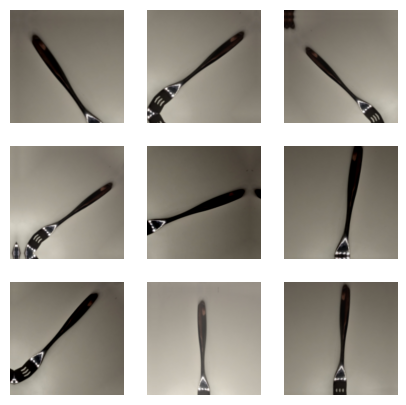

In [86]:
plt.figure(figsize=(5, 5))
for images, _ in train_dataset.take(1):
    for i in range(9):
        augmented_images = data_augmentation(images, training=True)
        ax = plt.subplot(3, 3, i+1)
        plt.imshow(augmented_images[0].numpy().astype("uint8"))
        plt.axis("off")

In [87]:
model = Sequential([
    data_augmentation,
    layers.Rescaling(1./255),

    layers.Conv2D(16, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.2),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.2),

    layers.GlobalAveragePooling2D(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(5, activation='softmax')
])

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [89]:
model.build(input_shape=(None, 224, 224, 3))  # batch_size None
model.summary()

Model: "sequential_15"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential_14 (Sequential)  (None, 224, 224, 3)       0         
                                                                 
 rescaling_7 (Rescaling)     (None, 224, 224, 3)       0         
                                                                 
 conv2d_19 (Conv2D)          (None, 222, 222, 16)      448       
                                                                 
 max_pooling2d_19 (MaxPooli  (None, 111, 111, 16)      0         
 ng2D)                                                           
                                                                 
 dropout_17 (Dropout)        (None, 111, 111, 16)      0         
                                                                 
 conv2d_20 (Conv2D)          (None, 109, 109, 32)      4640      
                                                     

In [90]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=50,
    callbacks=[early_stop]
)

Epoch 1/50


2026-04-03 12:56:50.811339: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape insequential_15/dropout_17/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


6/6 [==============================] - 2s 62ms/step - loss: 1.6336 - accuracy: 0.2000 - val_loss: 1.6063 - val_accuracy: 0.0571
Epoch 2/50
6/6 [==============================] - 0s 30ms/step - loss: 1.6177 - accuracy: 0.2343 - val_loss: 1.6060 - val_accuracy: 0.2286
Epoch 3/50
6/6 [==============================] - 0s 22ms/step - loss: 1.5641 - accuracy: 0.2914 - val_loss: 1.5963 - val_accuracy: 0.1714
Epoch 4/50
6/6 [==============================] - 0s 23ms/step - loss: 1.5799 - accuracy: 0.2457 - val_loss: 1.5839 - val_accuracy: 0.4000
Epoch 5/50
6/6 [==============================] - 0s 21ms/step - loss: 1.5330 - accuracy: 0.3600 - val_loss: 1.5601 - val_accuracy: 0.3714
Epoch 6/50
6/6 [==============================] - 0s 21ms/step - loss: 1.5107 - accuracy: 0.3600 - val_loss: 1.5350 - val_accuracy: 0.4857
Epoch 7/50
6/6 [==============================] - 0s 24ms/step - loss: 1.4757 - accuracy: 0.3429 - val_loss: 1.4839 - val_accuracy: 0.4286
Epoch 8/50
6/6 [======================

In [91]:
test_loss, test_acc = model.evaluate(test_dataset)
print(f"Test accuracy: {test_acc:.2f}")

2/2 [==============================] - 0s 20ms/step - loss: 0.8735 - accuracy: 0.6000
Test accuracy: 0.60


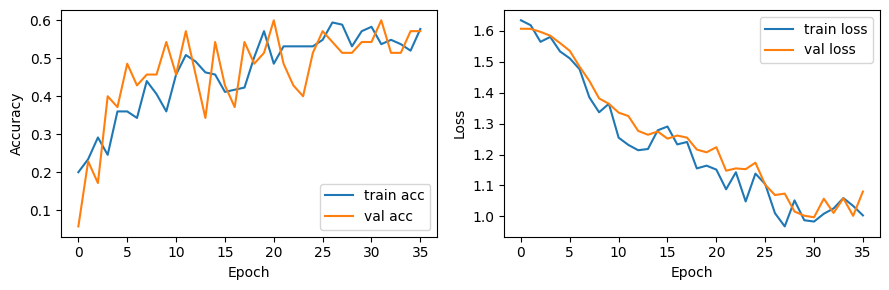

In [106]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3))

ax1.plot(history.history['accuracy'], label='train acc')
ax1.plot(history.history['val_accuracy'], label='val acc')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()

ax2.plot(history.history['loss'], label='train loss')
ax2.plot(history.history['val_loss'], label='val loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()

plt.tight_layout()
plt.show()

1/1 [==============================] - 0s 15ms/step


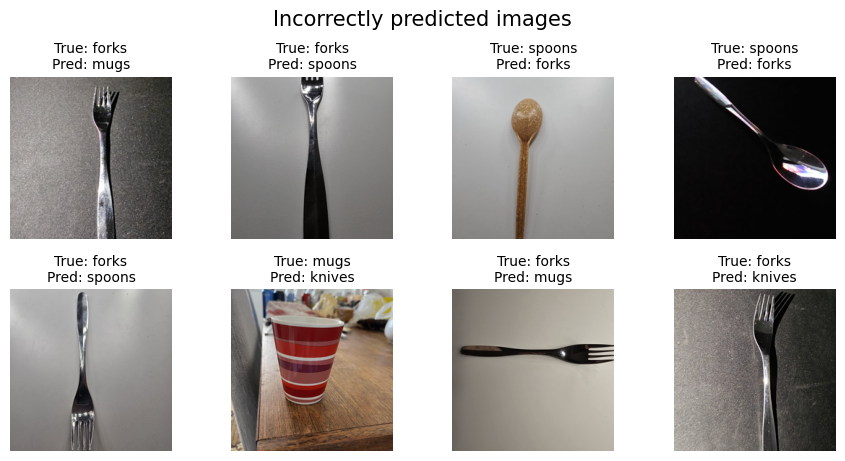

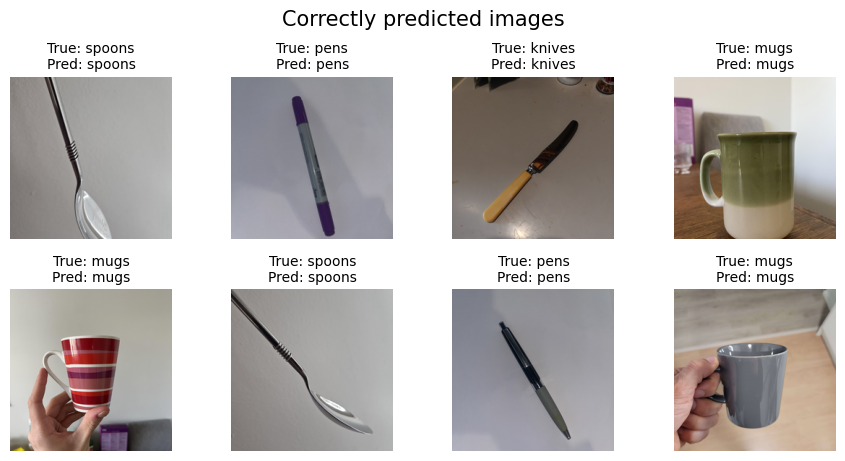

In [114]:
class_names = ['forks', 'knives', 'mugs', 'pens', 'spoons']

def collect_images(dataset, model):
    correct, wrong = [], []
    for images, labels in dataset.take(1):
        preds = model.predict(images)
        pred_labels = np.argmax(preds, axis=1)
        true_labels = np.argmax(labels.numpy(), axis=1)
        for img, t, p in zip(images, true_labels, pred_labels):
            entry = (img.numpy().astype("uint8"), class_names[t], class_names[p])
            if t == p:
                correct.append(entry)
            else:
                wrong.append(entry)
    return correct, wrong

def plot_images(images_list, title, n=8):   # n = amount of images
    num = min(n, len(images_list))
    plt.figure(figsize=(9,9))
    for i in range(num):
        ax = plt.subplot(4,4,i+1)
        plt.imshow(images_list[i][0])
        plt.title(f"True: {images_list[i][1]}\nPred: {images_list[i][2]}", fontsize=10)
        plt.axis("off")
    plt.suptitle(title, fontsize=15)
    plt.tight_layout()
    plt.show()

correct_images, wrong_images = collect_images(test_dataset, model)

plot_images(wrong_images, "Incorrectly predicted images")
plot_images(correct_images, "Correctly predicted images")